In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [5]:
def quantize_at_bitwidth(tensor, bits):


    # Compute quantization range
    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    # Maximum absolute value
    max_abs = np.max(np.abs(tensor))

    # Compute scale
    scale = max_abs / q_max

    # Quantize
    quantized = np.round(tensor / scale)

    quantized = np.clip(quantized, q_min, q_max)

    quantized = quantized.astype(np.int32)

    # Dequantize
    dequantized = quantized.astype(np.float32) * scale

    return quantized, dequantized, scale

In [6]:
def calculate_metrics(original, dequantized):

    error = original - dequantized

    mae = np.mean(np.abs(error))

    mse = np.mean(error ** 2)

    max_error = np.max(np.abs(error))

    return mae, mse, max_error

In [7]:
bit_widths = [8,6,4]

results = []

dequantized_values = {}

for bits in bit_widths:

    q, dq, scale = quantize_at_bitwidth(tensor, bits)

    mae, mse, max_error = calculate_metrics(tensor, dq)

    q_min = -(2 ** (bits - 1)) + 1

    q_max = (2 ** (bits - 1)) - 1

    levels = q_max - q_min + 1

    results.append([
        bits,
        q_min,
        q_max,
        levels,
        scale,
        mae,
        mse,
        max_error
    ])

    dequantized_values[bits] = dq

    print("="*60)

    print(bits,"Bit")

    print("Scale =",scale)

    print("\nQuantized")

    print(q)

    print("\nDequantized")

    print(dq)

    print("\nMAE =",mae)

    print("MSE =",mse)

    print("Max Error =",max_error)

8 Bit
Scale = 0.018897638

Quantized
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]

Dequantized
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]

MAE = 0.0037007749
MSE = 2.1638e-05
Max Error = 0.007874012
6 Bit
Scale = 0.077419356

Quantized
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]

Dequantized
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]

MAE = 0.015161285
MSE = 0.00036316324
Max Error = 0.032258064
4 Bit
Scale = 0.34285715

Quantized
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]

Dequantized
[[-1.7142857  -1.0285715   0.          0.6857143   1.3714286 ]
 [-2.4        -0.34285715  0.34285715  1.0285715   2.057143  ]]

MAE = 0.06714286
MSE = 0.0071224505
Max Error = 0.14285715


In [8]:
print("="*100)

print("{:<8}{:<10}{:<10}{:<10}{:<12}{:<12}{:<12}{:<12}".format(
    "Bits",
    "q_min",
    "q_max",
    "Levels",
    "Scale",
    "MAE",
    "MSE",
    "Max Error"
))

print("="*100)

for row in results:

    print("{:<8}{:<10}{:<10}{:<10}{:<12.6f}{:<12.6f}{:<12.6f}{:<12.6f}".format(*row))

Bits    q_min     q_max     Levels    Scale       MAE         MSE         Max Error   
8       -127      127       255       0.018898    0.003701    0.000022    0.007874    
6       -31       31        63        0.077419    0.015161    0.000363    0.032258    
4       -7        7         15        0.342857    0.067143    0.007122    0.142857    


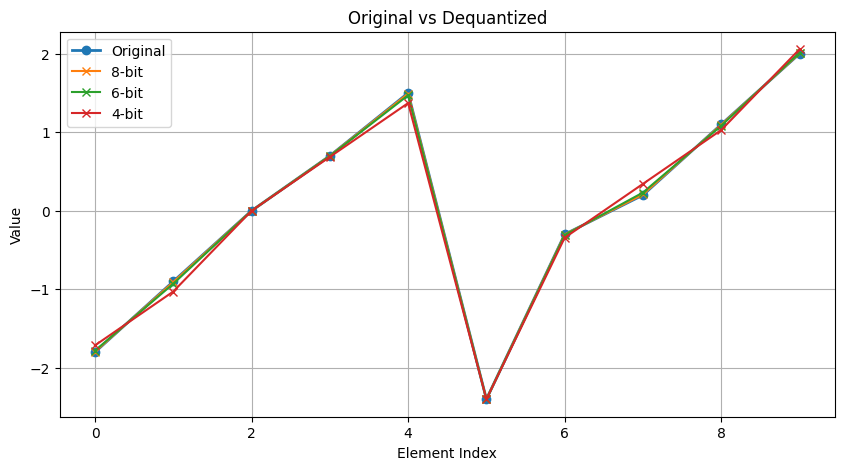

In [9]:
original = tensor.flatten()

x = np.arange(len(original))

plt.figure(figsize=(10,5))

plt.plot(x, original,
         marker='o',
         linewidth=2,
         label='Original')

for bits in bit_widths:

    plt.plot(
        x,
        dequantized_values[bits].flatten(),
        marker='x',
        label=f"{bits}-bit"
    )

plt.title("Original vs Dequantized")

plt.xlabel("Element Index")

plt.ylabel("Value")

plt.grid(True)

plt.legend()

plt.show()

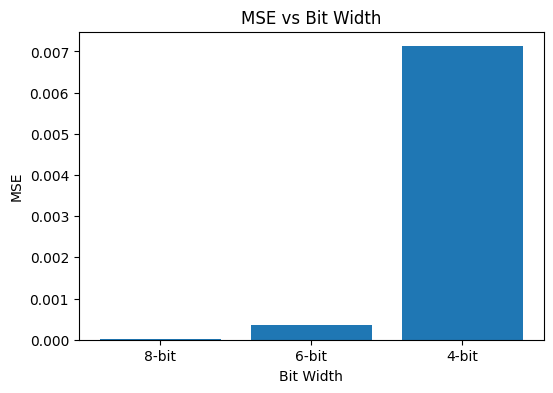

In [10]:
mse_values = [row[6] for row in results]

plt.figure(figsize=(6,4))

plt.bar(
    ['8-bit','6-bit','4-bit'],
    mse_values
)

plt.title("MSE vs Bit Width")

plt.xlabel("Bit Width")

plt.ylabel("MSE")

plt.show()

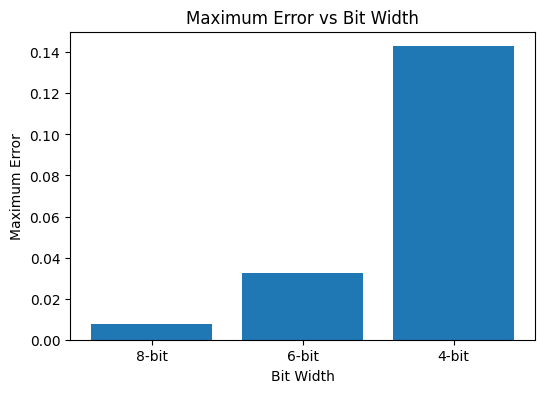

In [11]:
max_errors = [row[7] for row in results]

plt.figure(figsize=(6,4))

plt.bar(
    ['8-bit','6-bit','4-bit'],
    max_errors
)

plt.title("Maximum Error vs Bit Width")

plt.xlabel("Bit Width")

plt.ylabel("Maximum Error")

plt.show()